# Laboratorio 3: Reconocimiento de Lenguaje de Señas (ASL)
### Data Science | Universidad del Valle de Guatemala
**Sección 10 | Ing. Lynette García**

**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git

## Librerías y configuración

In [1]:
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid")
%matplotlib inline

## Descarga del dataset

El dataset se descarga de Kaggle (`grassknoted/asl-alphabet`) usando `kagglehub`, que se encarga de bajarlo y cachearlo localmente:

```bash
pip install kagglehub --break-system-packages
```

Con eso ya se puede correr la celda de abajo (descarga la primera vez y después usa el caché).

In [2]:
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

DATA_DIR = Path(path) / "asl_alphabet_train" / "asl_alphabet_train"

clases = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Cantidad de clases encontradas: {len(clases)}")
print(clases)

C:\Users\adria\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\adria\.cache\kagglehub\datasets\grassknoted\asl-alphabet\versions\1
Cantidad de clases encontradas: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Análisis Exploratorio de Datos

Preguntas guía para el análisis:

- ¿Cuántas imágenes hay por clase? ¿Está balanceado el dataset?
- ¿Qué resolución y formato tienen las imágenes? ¿Es consistente entre clases?
- ¿Qué tanta variabilidad hay dentro de una misma letra (ángulo, iluminación, fondo, tono de piel)?
- ¿Qué letras se parecen visualmente entre sí y podrían confundir al modelo?
- ¿Cómo se va a armar el conjunto de train/val/test a partir de estos datos?

### Distribución de clases (¿balanceado?)

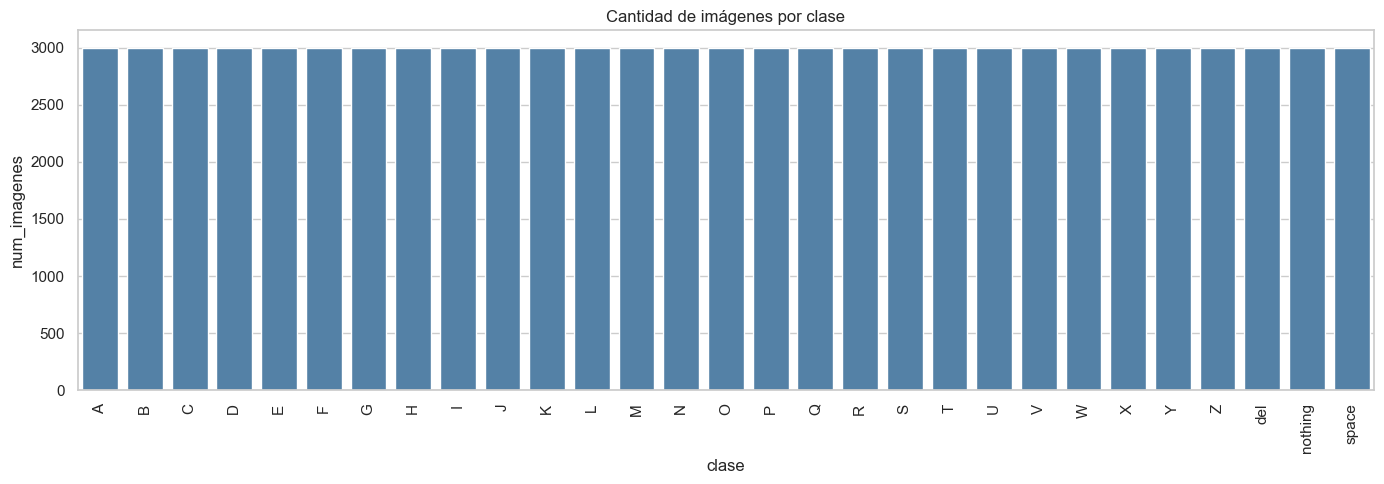

       num_imagenes
count          29.0
mean         3000.0
std             0.0
min          3000.0
25%          3000.0
50%          3000.0
75%          3000.0
max          3000.0


In [ ]:
conteo = {c: len(list((DATA_DIR / c).glob("*.jpg"))) for c in clases}
df_conteo = pd.DataFrame(conteo.items(), columns=["clase", "num_imagenes"]).sort_values("clase")

plt.figure(figsize=(14, 5))
sns.barplot(data=df_conteo, x="clase", y="num_imagenes", color="steelblue")
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por clase")
plt.tight_layout()
plt.show()

print(df_conteo.describe())

El dataset de Kaggle trae ~3,000 imágenes por clase, y se puede observar que está balanceado.

### Resolución y formato de las imágenes

In [5]:
muestras_check = []
for c in random.sample(clases, 8):
    archivo = random.choice(list((DATA_DIR / c).glob("*.jpg")))
    with Image.open(archivo) as img:
        muestras_check.append({
            "clase": c,
            "archivo": archivo.name,
            "tamano": img.size,
            "modo": img.mode,
            "formato": img.format,
        })

pd.DataFrame(muestras_check)

,clase,archivo,tamano,modo,formato
0,U,U1376.jpg,"(200, 200)",RGB,JPEG
1,D,D793.jpg,"(200, 200)",RGB,JPEG
2,A,A308.jpg,"(200, 200)",RGB,JPEG
3,X,X1319.jpg,"(200, 200)",RGB,JPEG
4,I,I475.jpg,"(200, 200)",RGB,JPEG
5,H,H2554.jpg,"(200, 200)",RGB,JPEG
6,Z,Z1115.jpg,"(200, 200)",RGB,JPEG
7,E,E1108.jpg,"(200, 200)",RGB,JPEG


Según la descripción del dataset, todas las imágenes deberían ser JPG de 200x200 a color (modo RGB). La celda anterior confirma esto con una muestra aleatoria.

### Ejemplos de letras y variabilidad dentro de una clase

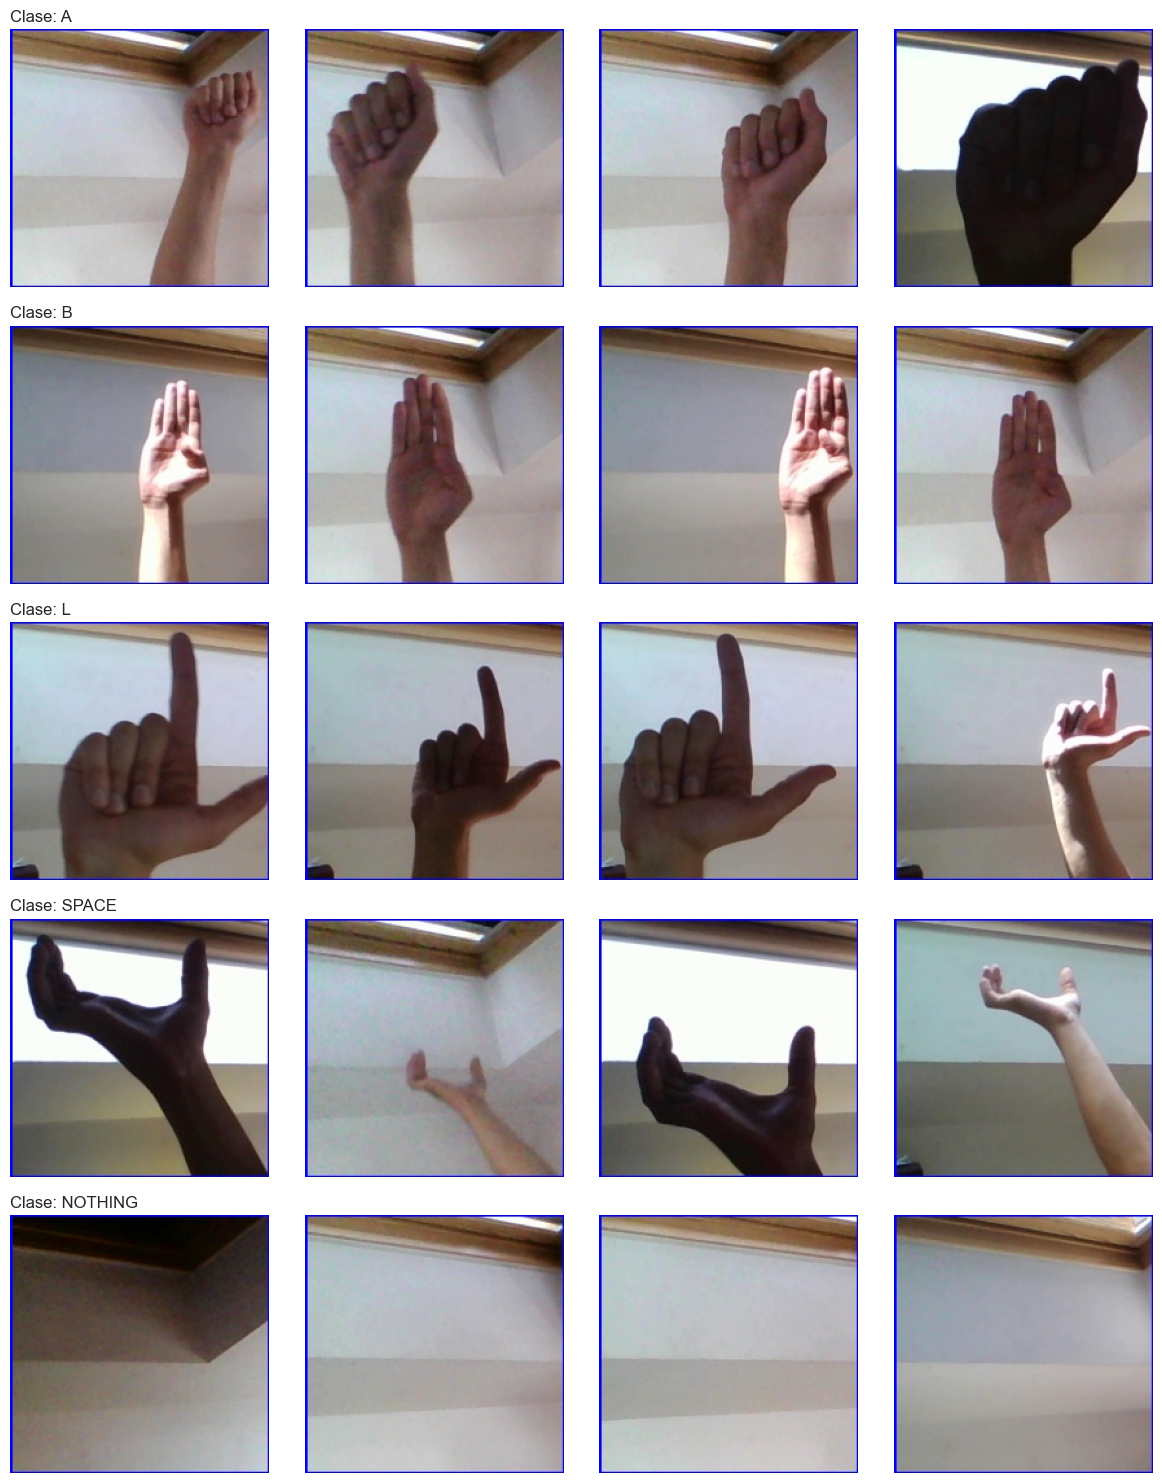

In [6]:
letras_ejemplo = ["A", "B", "L", "SPACE", "NOTHING"]  # ajustar a 5+ letras de interés
n_muestras = 4

fig, axes = plt.subplots(len(letras_ejemplo), n_muestras, figsize=(3 * n_muestras, 3 * len(letras_ejemplo)))

for i, letra in enumerate(letras_ejemplo):
    archivos = random.sample(list((DATA_DIR / letra).glob("*.jpg")), n_muestras)
    for j, archivo in enumerate(archivos):
        img = Image.open(archivo)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(letra, fontsize=14)
    axes[i, 0].set_title(f"Clase: {letra}", loc="left", fontsize=12)

plt.tight_layout()
plt.show()

Con esto se ve la variabilidad dentro de una misma clase: cambia el fondo, la iluminación, y ligeramente el ángulo de la mano, aunque en general las fotos del dataset están tomadas en condiciones bastante controladas (mismo tipo de fondo, misma persona en muchas series consecutivas).

### Letras que se confunden visualmente entre sí

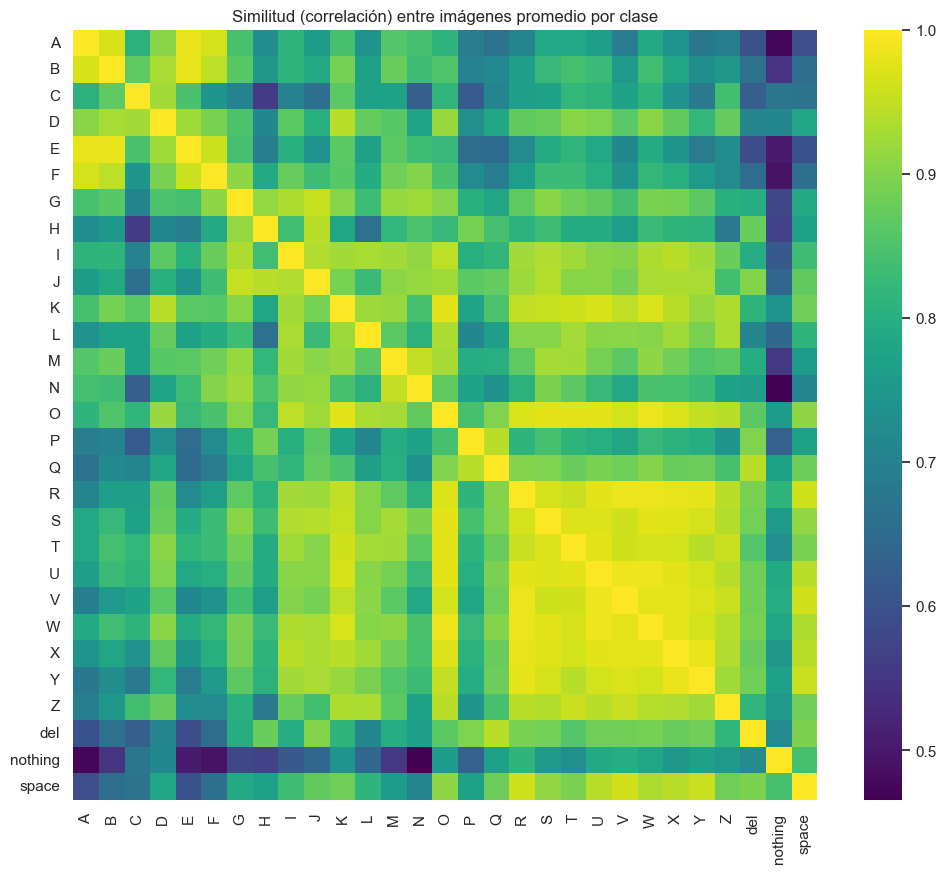

,clase_1,clase_2,similitud
371,U,W,0.986075
370,U,V,0.985785
343,R,V,0.985028
344,R,W,0.983773
308,O,W,0.983728
391,X,Y,0.983185
30,B,E,0.981238
345,R,X,0.980811
3,A,E,0.980112
379,V,X,0.978960


In [7]:
def imagen_promedio(clase, n=200):
    archivos = random.sample(list((DATA_DIR / clase).glob("*.jpg")), n)
    acumulado = None
    for archivo in archivos:
        img = np.array(Image.open(archivo).convert("L").resize((64, 64)), dtype=np.float32)
        acumulado = img if acumulado is None else acumulado + img
    return (acumulado / n).flatten()

promedios = {c: imagen_promedio(c) for c in clases}
df_prom = pd.DataFrame(promedios).T  # filas = clase, columnas = pixeles

# similitud entre clases (correlación entre imágenes promedio)
correlacion = df_prom.T.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="viridis")
plt.title("Similitud (correlación) entre imágenes promedio por clase")
plt.show()

# top pares más parecidos (excluyendo la diagonal)
pares = []
for i, c1 in enumerate(clases):
    for c2 in clases[i+1:]:
        pares.append((c1, c2, correlacion.loc[c1, c2]))

df_pares = pd.DataFrame(pares, columns=["clase_1", "clase_2", "similitud"]).sort_values("similitud", ascending=False)
df_pares.head(15)

Este análisis usa la imagen promedio de cada clase (en escala de grises, 64x64) y calcula qué tan correlacionadas están entre sí. Los pares con similitud más alta fueron U/W (0.986), U/V (0.986), R/V (0.985), R/W (0.984), O/W (0.984), X/Y (0.983) y B/E (0.981) — no coincide del todo con los pares que se mencionan típicamente para este dataset (M/N/S, U/V/R), aunque U/V y R/V sí aparecen. Esto tiene sentido porque son letras con la mano en posiciones cerradas o verticales muy similares entre sí. Hay que tomar el resultado con cuidado: la correlación se calculó sobre la imagen promedio en escala de grises, así que también puede estar capturando similitudes de fondo/iluminación y no solo la forma de la mano; por eso conviene revisar visualmente estos pares antes de asumir que son los que más van a confundir al modelo.

### Construcción del conjunto de entrenamiento / validación / prueba

In [8]:
N_POR_CLASE = 700  # submuestra por clase

filas = []
for c in clases:
    archivos = list((DATA_DIR / c).glob("*.jpg"))
    seleccion = random.sample(archivos, min(N_POR_CLASE, len(archivos)))
    for archivo in seleccion:
        filas.append({"ruta": str(archivo), "clase": c})

df_dataset = pd.DataFrame(filas)
print(f"Total de imágenes en la submuestra: {len(df_dataset)}")

# split estratificado 70/15/15
train_df, temp_df = train_test_split(df_dataset, test_size=0.30, stratify=df_dataset["clase"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["clase"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Total de imágenes en la submuestra: 20300
Train: 14210  |  Val: 3045  |  Test: 3045


El set de prueba oficial de Kaggle viene con muy pocas imágenes a propósito, así que el train/val/test se arma a partir del set de entrenamiento: se toma una submuestra por clase (para no cargar 87,000 imágenes) y se divide 70% train / 15% val / 15% test, de forma estratificada para mantener el balance de clases en las tres partes.

## Preprocesamiento de las imágenes

Pasos aplicados antes de entrenar:

1. **Reducción de resolución**: de 200x200 a 64x64. Con 29 clases y varios modelos a comparar, entrenar a 200x200 sería muy pesado para el tiempo del laboratorio; 64x64 conserva la forma general de la mano y los dedos, que es lo relevante para distinguir las señas.
2. **Normalización**: valores de píxel escalados de [0, 255] a [0, 1], y luego estandarizados con media/desviación estándar (por canal) para que el entrenamiento converja más rápido.
3. **Conversión a RGB**: por si alguna imagen viene en otro modo de color.
4. **Sin recortes ni rotaciones en esta etapa** — eso se deja para la sección de *image augmentation* que pide el ejercicio 7, más adelante en el laboratorio.

In [9]:
IMG_SIZE = 64

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),  # escala a [0, 1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class ASLDataset(Dataset):
    def __init__(self, dataframe, clases, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.clase_a_idx = {c: i for i, c in enumerate(clases)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        fila = self.df.iloc[idx]
        img = Image.open(fila["ruta"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.clase_a_idx[fila["clase"]]
        return img, label

train_dataset = ASLDataset(train_df, clases, transform)
val_dataset = ASLDataset(val_df, clases, transform)
test_dataset = ASLDataset(test_df, clases, transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# verificación rápida
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)

torch.Size([64, 3, 64, 64]) torch.Size([64])


## Plan para procesamiento de imagenes

Para poder entrenar el modelo correctamente, primero es necesario preparar las imágenes del dataset. La idea es dejar todos los datos en un formato uniforme y más fácil de procesar para la red neuronal.

Lo primero que se hará es redimensionar todas las imágenes a un tamaño fijo. Esto es importante porque el modelo necesita que todas las entradas tengan las mismas dimensiones.

Luego, se normalizarán los valores de los píxeles, pasando de un rango de 0 a 255 a un rango de 0 a 1. Esto ayuda a que el entrenamiento sea más estable y que el modelo aprenda de forma más eficiente.

También se transformarán las etiquetas (las letras del alfabeto) a valores numéricos, ya que el modelo no puede trabajar directamente con texto.

Después, el dataset se dividirá en conjuntos de entrenamiento y validación, para poder evaluar qué tan bien está aprendiendo el modelo y evitar que simplemente memorice los datos.

Además, se aplicarán algunas técnicas de aumento de datos (data augmentation), como pequeñas rotaciones, cambios de brillo o zoom. Esto permite generar variaciones de las imágenes originales y ayuda a que el modelo generalice mejor.

## Selección de arquitectura de modelos

Con el dataset preprocesado se proponen las siguientes arquitecturas a entrenar y comparar en la entrega final. La selección busca cubrir los cuatro tipos que pide el laboratorio: dos CNN de distinta complejidad, una red fully-connected simple, y un algoritmo no basado en deep learning.

### CNN 1 — Baseline
Arquitectura convolucional simple, 3 bloques Conv+ReLU+MaxPool, sin regularización adicional.
Sirve como punto de referencia: si esta ya da buen desempeño, no se justifica algo más complejo.

### CNN 2 — Con regularización (BatchNorm + Dropout)
Misma profundidad general pero con BatchNorm después de cada convolución (estabiliza y acelera
el entrenamiento) y Dropout antes de las capas densas (para controlar overfitting, dado que con
700 img/clase el riesgo es alto). Se espera que generalice mejor que la CNN 1, especialmente
en las letras que se confunden visualmente (M/N/S, U/V/R).

### Red Fully-Connected (MLP)
Red densa simple sobre los píxeles aplanados (64*64*3 = 12,288 features). Se usa como comparación
para cuantificar qué tanto aporta la estructura convolucional (invariancia espacial) frente a
una red que no la tiene.

### Random Forest
Se eligió Random Forest sobre SVM/KNN por tres razones:
**Costo computacional**: SVM con kernel no lineal escala mal con muchas muestras; KNN requiere calcular distancias contra todo el train set en cada predicción, lento con este volumen de datos.
**Robustez sin mucho tuning**: RF maneja bien alta dimensionalidad sin necesitar escalado de
   features y es menos sensible a hiperparámetros que SVM.
**Interpretabilidad**: permite ver qué regiones/píxeles pesan más (feature importance).

Dado que 12,288 features crudas son demasiadas para un RF eficiente, se reduce dimensionalidad
con **PCA** antes de entrenar (se documentará la varianza explicada retenida).

In [ ]:
import torch.nn.functional as F

# ============ CNN 1: Baseline ============
class CNN1(nn.Module):
    def __init__(self, n_clases=29):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64->32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32->16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16->8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============ CNN 2: con BatchNorm + Dropout ============
class CNN2(nn.Module):
    def __init__(self, n_clases=29):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),  # 64->32

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),  # 32->16

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2), # 16->8
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


# ============ MLP: Fully-connected simple ============
class MLPSimple(nn.Module):
    def __init__(self, n_clases=29, img_size=64):
        super().__init__()
        in_features = img_size * img_size * 3
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, n_clases)
        )

    def forward(self, x):
        return self.net(x)


# Verificación rápida de dimensiones con un batch real
imgs, labels = next(iter(train_loader))
for nombre, modelo in [("CNN1", CNN1()), ("CNN2", CNN2()), ("MLP", MLPSimple())]:
    salida = modelo(imgs)
    n_params = sum(p.numel() for p in modelo.parameters())
    print(f"{nombre}: salida {tuple(salida.shape)} | parámetros: {n_params:,}")

CNN1: salida (64, 29) | parámetros: 2,198,109
CNN2: salida (64, 29) | parámetros: 2,245,437
MLP: salida (64, 29) | parámetros: 6,430,749


## Entrenamiento y evaluación de los modelos CNN

Se entrenan `CNN1` (baseline) y `CNN2` (con BatchNorm + Dropout) con el mismo dataset, mismo número de épocas y mismo optimizador, para que la comparación sea justa. Al final se evalúa cada una en el set de test y se elige la que tenga mejor accuracy/F1.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")

def entrenar_modelo(modelo, train_loader, val_loader, epochs=10, lr=1e-3):
    modelo = modelo.to(device)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss()

    historial = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        modelo.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            salida = modelo(imgs)
            loss = criterio(salida, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
        train_loss /= len(train_loader.dataset)

        modelo.eval()
        val_loss, correctos = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                salida = modelo(imgs)
                loss = criterio(salida, labels)
                val_loss += loss.item() * imgs.size(0)
                correctos += (salida.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correctos / len(val_loader.dataset)

        historial["train_loss"].append(train_loss)
        historial["val_loss"].append(val_loss)
        historial["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

    return modelo, historial


def evaluar_en_test(modelo, test_loader):
    modelo.eval()
    correctos, total = 0, 0
    todas_preds, todas_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            salida = modelo(imgs)
            preds = salida.argmax(1)
            correctos += (preds == labels).sum().item()
            total += labels.size(0)
            todas_preds.extend(preds.cpu().numpy())
            todas_labels.extend(labels.cpu().numpy())
    acc = correctos / total
    print(f"Test accuracy: {acc:.4f}")
    return acc, todas_preds, todas_labels

Usando: cpu


### Entrenamiento de CNN1

In [ ]:
cnn1 = CNN1(n_clases=len(clases))
cnn1, hist_cnn1 = entrenar_modelo(cnn1, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 1.8376 | val_loss: 0.8848 | val_acc: 0.7061
Epoch 2/10 | train_loss: 0.4729 | val_loss: 0.3711 | val_acc: 0.8818
Epoch 3/10 | train_loss: 0.2169 | val_loss: 0.2203 | val_acc: 0.9310
Epoch 4/10 | train_loss: 0.1204 | val_loss: 0.2677 | val_acc: 0.9054
Epoch 5/10 | train_loss: 0.0870 | val_loss: 0.1736 | val_acc: 0.9465
Epoch 6/10 | train_loss: 0.0650 | val_loss: 0.1478 | val_acc: 0.9580
Epoch 7/10 | train_loss: 0.0623 | val_loss: 0.1800 | val_acc: 0.9570
Epoch 8/10 | train_loss: 0.0431 | val_loss: 0.1678 | val_acc: 0.9517
Epoch 9/10 | train_loss: 0.0490 | val_loss: 0.1892 | val_acc: 0.9452
Epoch 10/10 | train_loss: 0.0385 | val_loss: 0.2030 | val_acc: 0.9484


### Entrenamiento de CNN2

In [ ]:
cnn2 = CNN2(n_clases=len(clases))
cnn2, hist_cnn2 = entrenar_modelo(cnn2, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 1.3928 | val_loss: 0.8252 | val_acc: 0.7704
Epoch 2/10 | train_loss: 0.3305 | val_loss: 0.2162 | val_acc: 0.9527
Epoch 3/10 | train_loss: 0.1220 | val_loss: 0.1603 | val_acc: 0.9586
Epoch 4/10 | train_loss: 0.0897 | val_loss: 0.0684 | val_acc: 0.9826
Epoch 5/10 | train_loss: 0.0376 | val_loss: 0.1109 | val_acc: 0.9685
Epoch 6/10 | train_loss: 0.0485 | val_loss: 0.7282 | val_acc: 0.7711
Epoch 7/10 | train_loss: 0.3283 | val_loss: 0.2814 | val_acc: 0.9090
Epoch 8/10 | train_loss: 0.1953 | val_loss: 0.0597 | val_acc: 0.9826
Epoch 9/10 | train_loss: 0.0454 | val_loss: 0.3023 | val_acc: 0.8936
Epoch 10/10 | train_loss: 0.4322 | val_loss: 0.0915 | val_acc: 0.9796


### Curvas de entrenamiento

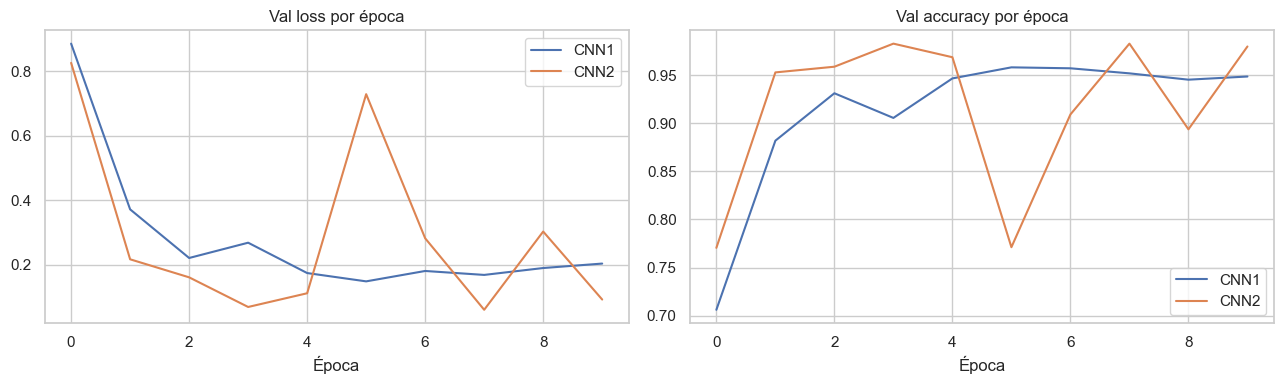

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_cnn1["val_loss"], label="CNN1")
axes[0].plot(hist_cnn2["val_loss"], label="CNN2")
axes[0].set_title("Val loss por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(hist_cnn1["val_acc"], label="CNN1")
axes[1].plot(hist_cnn2["val_acc"], label="CNN2")
axes[1].set_title("Val accuracy por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.show()

### Evaluación en test y selección del mejor

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("== CNN1 ==")
acc1, preds1, labels1 = evaluar_en_test(cnn1, test_loader)

print("\n== CNN2 ==")
acc2, preds2, labels2 = evaluar_en_test(cnn2, test_loader)

mejor_nombre, mejor_modelo, mejor_preds, mejor_labels = (
    ("CNN1", cnn1, preds1, labels1) if acc1 >= acc2 else ("CNN2", cnn2, preds2, labels2)
)
print(f"\nMejor modelo CNN: {mejor_nombre} (test acc: {max(acc1, acc2):.4f})")

print(classification_report(mejor_labels, mejor_preds, target_names=clases))

== CNN1 ==
Test accuracy: 0.9471

== CNN2 ==
Test accuracy: 0.9806

Mejor modelo CNN: CNN2 (test acc: 0.9806)
              precision    recall  f1-score   support

           A       0.99      0.97      0.98       105
           B       0.95      1.00      0.98       105
           C       1.00      1.00      1.00       105
           D       0.98      0.99      0.99       105
           E       0.99      0.92      0.96       105
           F       0.97      0.99      0.98       105
           G       0.95      0.95      0.95       105
           H       0.95      0.95      0.95       105
           I       0.99      0.98      0.99       105
           J       0.99      0.99      0.99       105
           K       0.99      0.98      0.99       105
           L       1.00      1.00      1.00       105
           M       0.95      1.00      0.98       105
           N       0.98      0.97      0.98       105
           O       1.00      0.99      1.00       105
           P       1.00  

CNN2 ganó (0.9806 vs 0.9471 de CNN1) — el BatchNorm + Dropout sí ayudaron a generalizar, aunque su entrenamiento fue más inestable (la val accuracy se cae a 0.77 en la época 5 antes de recuperarse). No es overfitting, porque el accuracy en test terminó siendo incluso mejor que en validación.

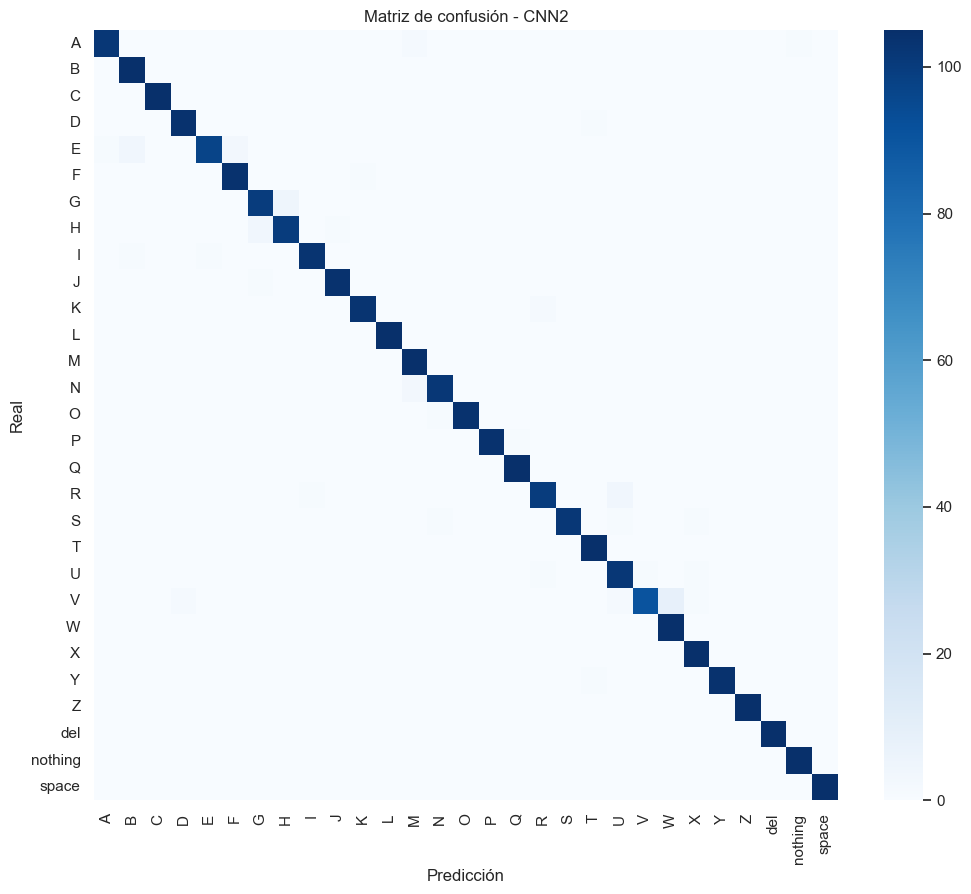

In [ ]:
cm = confusion_matrix(mejor_labels, mejor_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=clases, yticklabels=clases, cmap="Blues")
plt.title(f"Matriz de confusión - {mejor_nombre}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

La matriz de confusión de CNN2 confirma lo que había salido en el EDA: el error más visible es entre V y W, que estaba dentro del grupo U/V/W/R que salió como más parecido por la posición vertical de los dedos.

## Modelo de red neuronal simple (fully-connected) y comparación con las CNN

Se entrena `MLPSimple` con el mismo pipeline (mismo `entrenar_modelo`, mismos train/val/test) para que la comparación contra CNN1 y CNN2 sea justa.

In [16]:
mlp = MLPSimple(n_clases=len(clases), img_size=IMG_SIZE)
mlp, hist_mlp = entrenar_modelo(mlp, train_loader, val_loader, epochs=10, lr=1e-3)

Epoch 1/10 | train_loss: 2.6320 | val_loss: 1.8844 | val_acc: 0.4016
Epoch 2/10 | train_loss: 1.8604 | val_loss: 1.3701 | val_acc: 0.5560
Epoch 3/10 | train_loss: 1.5066 | val_loss: 1.1391 | val_acc: 0.6164
Epoch 4/10 | train_loss: 1.2925 | val_loss: 0.9740 | val_acc: 0.6831
Epoch 5/10 | train_loss: 1.1848 | val_loss: 0.8425 | val_acc: 0.7090
Epoch 6/10 | train_loss: 1.0623 | val_loss: 0.7801 | val_acc: 0.7281
Epoch 7/10 | train_loss: 0.9766 | val_loss: 0.7082 | val_acc: 0.7681
Epoch 8/10 | train_loss: 0.9138 | val_loss: 0.6855 | val_acc: 0.7612
Epoch 9/10 | train_loss: 0.9241 | val_loss: 0.6154 | val_acc: 0.7938
Epoch 10/10 | train_loss: 0.8875 | val_loss: 0.5680 | val_acc: 0.8033


### Evaluación del MLP en test

In [17]:
print("== MLP ==")
acc_mlp, preds_mlp, labels_mlp = evaluar_en_test(mlp, test_loader)

== MLP ==
Test accuracy: 0.8187


Se cumplió lo esperado, el MLP quedó en 0.8187 de test accuracy, bastante por debajo de las dos CNN (CNN2: 0.9806, CNN1: 0.9471), una diferencia de casi 16 puntos contra la mejor CNN. Al aplanar la imagen en un solo vector se pierde la relación espacial entre píxeles vecinos, y el MLP tiene que aprender a reconocer la forma de la mano sin esa ventaja, a diferencia de las capas convolucionales que sí explotan esa estructura local.

Vale la pena notar que el MLP todavía estaba mejorando en la época 10 (val_loss seguía bajando y val_acc seguía subiendo, sin señales de estancarse), así que con más épocas probablemente subiría algo más el accuracy — pero aun así es poco probable que alcance a las CNN, porque la limitación es de arquitectura (falta de estructura espacial), no solo de tiempo de entrenamiento.

## Modelo con otro algoritmo (Random Forest)

Se eligió Random Forest sobre SVM o KNN porque escala mejor con el volumen de datos y da información de importancia de características. Como Random Forest no trabaja bien con vectores de +12,000 dimensiones (una imagen 64x64x3 aplanada), primero se reduce dimensionalidad con PCA.

### Preparar los datos como vectores (sin la normalización de PyTorch, PCA no la necesita)

In [18]:
def cargar_arreglo(dataframe, img_size=64):
    X = np.zeros((len(dataframe), img_size * img_size * 3), dtype=np.float32)
    y = dataframe["clase"].values
    for i, ruta in enumerate(dataframe["ruta"].values):
        img = Image.open(ruta).convert("RGB").resize((img_size, img_size))
        X[i] = np.asarray(img, dtype=np.float32).flatten() / 255.0
    return X, y

X_train, y_train = cargar_arreglo(train_df)
X_test, y_test = cargar_arreglo(test_df)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (14210, 12288)  Test: (3045, 12288)


### PCA + Random Forest

In [19]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

pca = PCA(n_components=150, random_state=SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"Varianza explicada retenida con 150 componentes: {pca.explained_variance_ratio_.sum():.4f}")

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=SEED, n_jobs=-1)
rf.fit(X_train_pca, y_train)

preds_rf = rf.predict(X_test_pca)
acc_rf = accuracy_score(y_test, preds_rf)
print(f"Random Forest test accuracy: {acc_rf:.4f}")
print(classification_report(y_test, preds_rf))

Varianza explicada retenida con 150 componentes: 0.9620
Random Forest test accuracy: 0.9136
              precision    recall  f1-score   support

           A       0.88      0.90      0.89       105
           B       0.87      0.83      0.85       105
           C       0.97      0.97      0.97       105
           D       0.91      0.92      0.92       105
           E       0.83      0.87      0.85       105
           F       0.93      0.95      0.94       105
           G       0.95      0.90      0.93       105
           H       0.89      0.93      0.91       105
           I       0.88      0.93      0.90       105
           J       0.98      0.92      0.95       105
           K       0.92      0.97      0.94       105
           L       0.96      0.97      0.97       105
           M       0.91      0.91      0.91       105
           N       0.95      0.94      0.95       105
           O       0.96      0.90      0.93       105
           P       0.94      0.98      0.96

Con 150 componentes de PCA se retuvo el 96.2% de la varianza, y el Random Forest quedó en 0.9136 de test accuracy — mejor que el MLP (0.8187), pero por debajo de ambas CNN (CNN2: 0.9806, CNN1: 0.9471). Tiene sentido: al reducir con PCA y trabajar sobre los píxeles crudos (aunque comprimidos), captura algo de la estructura general de la imagen, pero no tanto como las convoluciones, que aprenden específicamente patrones locales de bordes y formas.

La letra con peor desempeño fue **U** (recall 0.76), justo una de las que ya había salido como más parecida a otras (U/W, U/V) en el análisis exploratorio y en la matriz de confusión de CNN2. E y R también quedaron entre las más bajas (recall ~0.86-0.87), reforzando que ese grupo de letras con los dedos en posición vertical es el punto más débil en todos los modelos, no solo en las CNN.

## Resumen comparativo de los 4 modelos

In [20]:
resumen_modelos = pd.DataFrame({
    "modelo": ["CNN1", "CNN2", "MLP (fully-connected)", "Random Forest (PCA)"],
    "test_accuracy": [acc1, acc2, acc_mlp, acc_rf],
}).sort_values("test_accuracy", ascending=False)

resumen_modelos

,modelo,test_accuracy
1,CNN2,0.980624
0,CNN1,0.947126
3,Random Forest (PCA),0.913629
2,MLP (fully-connected),0.818719


El ranking final quedó **CNN2 (0.9806) > CNN1 (0.9471) > Random Forest (0.9136) > MLP (0.8187)**. Las dos CNN se llevan el podio por bastante margen, lo cual confirma que para este problema la estructura espacial de la imagen (bordes, forma de los dedos, posición de la mano) es la señal más importante, y las convoluciones son las que mejor la explotan. El Random Forest con PCA quedó en un punto intermedio razonable — mejor que un modelo sin ninguna noción de estructura espacial (MLP), pero sin llegar a las CNN porque igual trabaja sobre una versión comprimida de los píxeles crudos, sin el sesgo inductivo de las convoluciones.

**CNN2 es el modelo que se usa para el ejercicio**, por ser el de mejor accuracy en test.